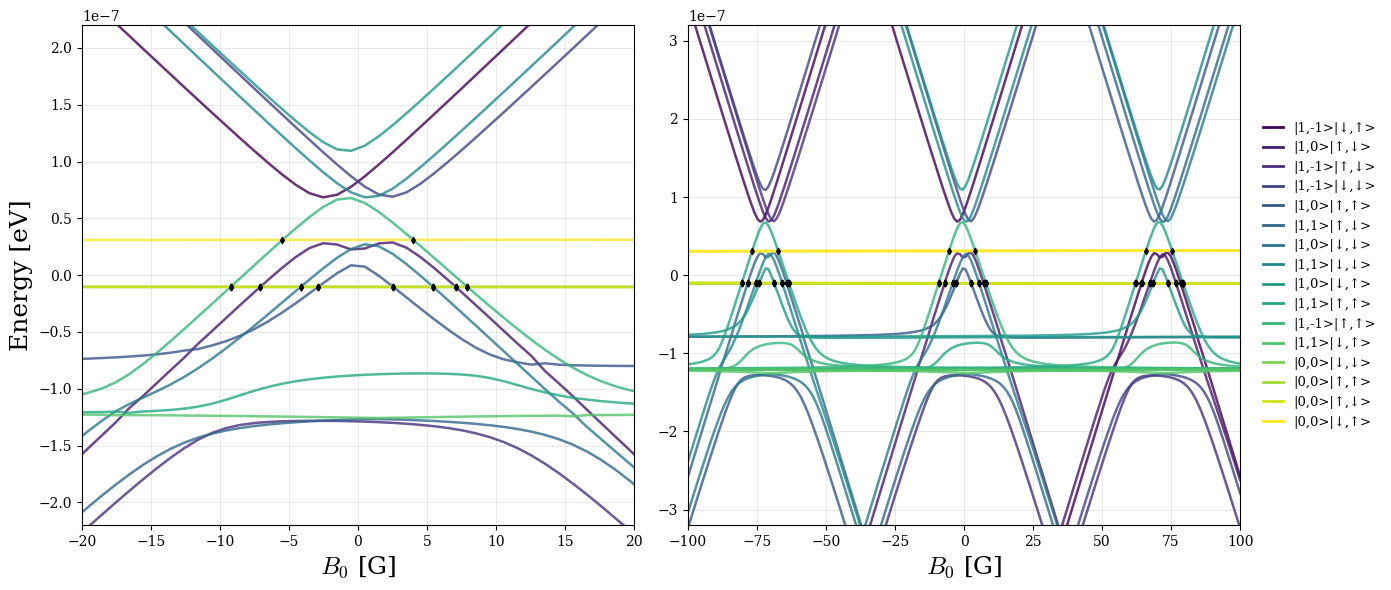

In [129]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"

def load(fname):
    with open(fname, "rb") as f:
        return pickle.load(f)

static = load("static.pickle")
pos    = load("positive_rwa.pickle")
neg    = load("negative_rwa.pickle")

B_static, E_static, labels = np.array(static["b_fields"]), np.array(static["energies"]), static["labels"]
B_pos, E_pos = np.array(pos["b_fields"]), np.array(pos["energies"])
B_neg, E_neg = np.array(neg["b_fields"]), np.array(neg["energies"])

n_states = len(labels)

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_states))
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))


for k, label in enumerate(labels):
    c = colors[k]
    ax[1].plot(B_static, E_static[:, k], color=c, lw=1.8, alpha=0.8)
    ax[0].plot(B_static, E_static[:, k], color=c, lw=1.8, alpha=0.8)
    ax[1].plot(B_pos,    E_pos[:, k],    color=c, lw=1.8, alpha=0.8)
    ax[1].plot(B_neg,    E_neg[:, k],    color=c, lw=1.8, alpha=0.8)

deg_static = find_degeneracies(B_static, E_static, labels)
deg_pos    = find_degeneracies(B_pos, E_pos, labels)
deg_neg    = find_degeneracies(B_neg, E_neg, labels)

for Bc, Ec in deg_static:
    ax[0].scatter(Bc, Ec, color='k', s=10, marker="d", zorder=10)
    ax[1].scatter(Bc, Ec, color='k', s=10, marker="d", zorder=10)
for Bc, Ec in np.vstack([deg_pos, deg_neg]):
    ax[1].scatter(Bc, Ec, color='k', s=10, marker="d", zorder=10)

for axis in ax:
    axis.set_xlabel(r"$B_0$ [G]", fontsize=18)
    axis.grid(True, ls="-", lw=0.4, alpha=0.5)

ax[0].set_ylim(-0.22e-6, 0.22e-6)
ax[1].set_ylim(-0.32e-6, 0.32e-6)
    
ax[0].set_xlim(-20, 20)
ax[1].set_xlim(-100, 100)
ax[0].set_ylabel(r"Energy [eV]", fontsize=18)

handles = [plt.Line2D([0], [0], color=colors[i], lw=2) for i in range(n_states)]
leg = ax[1].legend(
    handles,
    labels,
    fontsize=9.5,
    loc="center left",            
    bbox_to_anchor=(1.02, 0.5),   
    ncol=1,
    handlelength=1.5,
)


frame = leg.get_frame()
frame.set_facecolor("white")
frame.set_edgecolor("none")
frame.set_alpha(0.85)
frame.set_boxstyle("Square")

plt.tight_layout()
plt.savefig("figures/eigensim.png", dpi=500)

In [127]:
import numpy as np
from itertools import product

def find_degeneracies(B, E, labels, tol=1e-9):
    trip_idx = [i for i, l in enumerate(labels) if l.startswith('|1')]
    sing_idx = [i for i, l in enumerate(labels) if l.startswith('|0')]

    deg_points = []
    for i, j in product(trip_idx, sing_idx):
        e_i, e_j = E[:, i], E[:, j]
        diff = e_i - e_j
        sign_change = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]

        for k in sign_change:
            # linear interpolation, then refine with midpoint
            b0, b1 = B[k], B[k+1]
            d0, d1 = diff[k], diff[k+1]
            B_cross = b0 - d0 * (b1 - b0) / (d1 - d0)
            # one refinement step for accuracy
            for _ in range(2):
                d_cross = np.interp(B_cross, B, diff)
                dB = (b1 - b0) * d_cross / (d1 - d0)
                B_cross -= dB
            E_cross = 0.5 * (
                np.interp(B_cross, B, e_i) +
                np.interp(B_cross, B, e_j)
            )
            deg_points.append((B_cross, E_cross))

    return np.array(deg_points)